In [25]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import curve_fit


# Load data

In [26]:
traindf = pd.read_csv("../data/processed/train.csv")
valdf = pd.read_csv("../data/processed/val.csv")
testdf = pd.read_csv("../data/processed/test.csv")

We perform a regression task to predict `totalRent` for apartments in Germany from the available tabular features.  
The workflow below keeps the same modelling approach as the original notebook and compares:

- **Univariate Linear Regression**
- **Multivariate Linear Regression with `baseRent`**
- **Multivariate Linear Regression without `baseRent`**
- **Non-linear Regression** using `baseRent`**
- **Non-linear Regression** doesn't using `baseRent`**

# SPLIT DATA FOR MULTIVARIATE LINEAR REGRESSION

In [27]:
X_with_baserent_train = traindf.drop(columns=["totalRent"])
y_train = traindf["totalRent"]

X_with_baserent_val = valdf.drop(columns=["totalRent"])
y_val = valdf["totalRent"]

X_with_baserent_test = testdf.drop(columns=["totalRent"])
y_test = testdf["totalRent"]
    

# SPLIT DATA FOR NONLINEAR REGRESSION

In [28]:
X_without_baserent_train = traindf.drop(columns=["baseRent", "totalRent"])
X_without_baserent_val = valdf.drop(columns=["baseRent", "totalRent"])
X_without_baserent_test = testdf.drop(columns=["baseRent", "totalRent"])

In [29]:
x_col = "baseRent"   # đổi thành feature bạn muốn thử

X_nlr_train = traindf[x_col].values
X_nlr_vali= valdf[x_col].values
X_nlr_test= testdf[x_col].values

# Univariate Linear Regression

We fit one linear regression model per feature to see which single variable predicts `totalRent` best.  
Model selection is based on the validation set using **MAE**, **MSE**, **RMSE**, and **R²**.

In [30]:
feature_cols = [
    "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
    "baseRent", "livingSpace", "noRooms", "floor", "numberOfFloors",
    "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
    "garden", "regio2_freq"
]

target_col = "totalRent"

y_train = traindf[target_col].copy()
y_val   = valdf[target_col].copy()


def build_metric_row(model_name, family, feature, split_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "family": family,
        "feature": feature,
        "split": split_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }


def rank_models(df):
    ranked = df.copy()
    ranked["rank_MAE"] = ranked["MAE"].rank(method="min", ascending=True)
    ranked["rank_MSE"] = ranked["MSE"].rank(method="min", ascending=True)
    ranked["rank_RMSE"] = ranked["RMSE"].rank(method="min", ascending=True)
    ranked["rank_R2"] = ranked["R2"].rank(method="min", ascending=False)
    ranked["overall_rank"] = (
        ranked["rank_MAE"]
        + ranked["rank_MSE"]
        + ranked["rank_RMSE"]
        + ranked["rank_R2"]
    )
    return ranked.sort_values(
        by=["overall_rank", "RMSE", "MAE", "MSE", "R2"],
        ascending=[True, True, True, True, False]
    ).reset_index(drop=True)


def best_by_metric(df):
    results = []
    metric_rules = {
        "MAE": True,
        "MSE": True,
        "RMSE": True,
        "R2": False
    }

    for metric, ascending in metric_rules.items():
        best_row = df.sort_values(by=metric, ascending=ascending).iloc[0]
        results.append({
            "metric": metric,
            "best_model": best_row["model"],
            "family": best_row["family"],
            "feature": best_row["feature"],
            "value": best_row[metric]
        })

    return pd.DataFrame(results)


def nonlinear_model(x, theta1, theta2):
    x = np.asarray(x, dtype=float)
    denom = theta2 + x
    denom = np.where(np.abs(denom) < 1e-8, 1e-8, denom)
    return (theta1 * x) / denom


ulr_rows = []
ulr_models = {}
ulr_predictions = {}

for col in feature_cols:
    X_train_one = traindf[[col]]
    X_val_one   = valdf[[col]]

    model = LinearRegression()
    model.fit(X_train_one, y_train)

    y_train_pred = model.predict(X_train_one)
    y_val_pred   = model.predict(X_val_one)

    ulr_models[col] = model
    ulr_predictions[col] = {
        "train_true": y_train.values,
        "train_pred": y_train_pred,
        "val_true": y_val.values,
        "val_pred": y_val_pred
    }

    ulr_rows.append(
        build_metric_row(
            model_name=f"ULR_{col}",
            family="Univariate Linear Regression",
            feature=col,
            split_name="train",
            y_true=y_train,
            y_pred=y_train_pred
        )
    )

    ulr_rows.append(
        build_metric_row(
            model_name=f"ULR_{col}",
            family="Univariate Linear Regression",
            feature=col,
            split_name="val",
            y_true=y_val,
            y_pred=y_val_pred
        )
    )

ulr_results = pd.DataFrame(ulr_rows)
ulr_results
ulr_val_results = ulr_results[ulr_results["split"] == "val"].copy()

ulr_best_each_metric = best_by_metric(ulr_val_results)
ulr_val_ranked = rank_models(ulr_val_results)

display(ulr_best_each_metric)
display(ulr_val_ranked)

,metric,best_model,family,feature,value
0,MAE,ULR_baseRent,Univariate Linear Regression,baseRent,92.878925
1,MSE,ULR_baseRent,Univariate Linear Regression,baseRent,26141.081231
2,RMSE,ULR_baseRent,Univariate Linear Regression,baseRent,161.682037
3,R2,ULR_baseRent,Univariate Linear Regression,baseRent,0.728073


,model,family,feature,split,MAE,MSE,RMSE,R2,rank_MAE,rank_MSE,rank_RMSE,rank_R2,overall_rank
0,ULR_baseRent,Univariate Linear Regression,baseRent,val,92.878925,26141.081231,161.682037,0.728073,1.0,1.0,1.0,1.0,4.0
1,ULR_livingSpace,Univariate Linear Regression,livingSpace,val,194.620931,67795.645827,260.375970,0.294771,2.0,2.0,2.0,2.0,8.0
2,ULR_serviceCharge,Univariate Linear Regression,serviceCharge,val,200.216344,72207.026495,268.713651,0.248883,3.0,3.0,3.0,3.0,12.0
3,ULR_pricetrend,Univariate Linear Regression,pricetrend,val,216.878751,83016.749762,288.126274,0.136437,4.0,4.0,4.0,4.0,16.0
4,ULR_noRooms,Univariate Linear Regression,noRooms,val,221.655087,83267.959904,288.561882,0.133824,5.0,5.0,5.0,5.0,20.0
5,ULR_balcony,Univariate Linear Regression,balcony,val,226.956147,89674.082419,299.456311,0.067186,8.0,6.0,6.0,6.0,26.0
6,ULR_newlyConst,Univariate Linear Regression,newlyConst,val,224.884929,90137.381259,300.228881,0.062367,6.0,7.0,7.0,7.0,27.0
7,ULR_lift,Univariate Linear Regression,lift,val,227.124025,90943.628209,301.568613,0.053980,9.0,8.0,8.0,8.0,33.0
8,ULR_hasKitchen,Univariate Linear Regression,hasKitchen,val,226.937413,92068.939492,303.428640,0.042274,7.0,10.0,10.0,10.0,37.0
9,ULR_yearConstructed,Univariate Linear Regression,yearConstructed,val,229.454827,91279.273456,302.124599,0.050488,11.0,9.0,9.0,9.0,38.0


# Multivariate Linear Regression with `baseRent`

We now use the full selected feature set, including `baseRent`, to predict `totalRent`.

In [31]:

mlr_with_baserent = LinearRegression()
mlr_with_baserent.fit(X_with_baserent_train, y_train)

y_train_pred_mlr_with = mlr_with_baserent.predict(X_with_baserent_train)
y_val_pred_mlr_with   = mlr_with_baserent.predict(X_with_baserent_val)

mlr_with_baserent_results = pd.DataFrame([
    build_metric_row(
        model_name="MLR_with_baseRent",
        family="Multivariate Linear Regression with baseRent",
        feature="multiple_features_with_baseRent",
        split_name="train",
        y_true=y_train,
        y_pred=y_train_pred_mlr_with
    ),
    build_metric_row(
        model_name="MLR_with_baseRent",
        family="Multivariate Linear Regression with baseRent",
        feature="multiple_features_with_baseRent",
        split_name="val",
        y_true=y_val,
        y_pred=y_val_pred_mlr_with
    )
])

mlr_with_baserent_results

,model,family,feature,split,MAE,MSE,RMSE,R2
0,MLR_with_baseRent,Multivariate Linear Regression with baseRent,multiple_features_with_baseRent,train,87.590099,24843.391261,157.617865,0.742961
1,MLR_with_baseRent,Multivariate Linear Regression with baseRent,multiple_features_with_baseRent,val,87.405142,24693.279956,157.140956,0.743134


### Why compare a version without `baseRent`?

`baseRent` is one of the strongest rent-related predictors, so we also train a second multivariate model without it.  
This helps us measure how much of the predictive power comes from `baseRent` versus the remaining features.

In [32]:
mlr_without_baserent = LinearRegression()
mlr_without_baserent.fit(X_without_baserent_train, y_train)

y_train_pred_mlr_without = mlr_without_baserent.predict(X_without_baserent_train)
y_val_pred_mlr_without   = mlr_without_baserent.predict(X_without_baserent_val)

mlr_without_baserent_results = pd.DataFrame([
    build_metric_row(
        model_name="MLR_without_baseRent",
        family="Multivariate Linear Regression without baseRent",
        feature="multiple_features_without_baseRent",
        split_name="train",
        y_true=y_train,
        y_pred=y_train_pred_mlr_without
    ),
    build_metric_row(
        model_name="MLR_without_baseRent",
        family="Multivariate Linear Regression without baseRent",
        feature="multiple_features_without_baseRent",
        split_name="val",
        y_true=y_val,
        y_pred=y_val_pred_mlr_without
    )
])

mlr_without_baserent_results

,model,family,feature,split,MAE,MSE,RMSE,R2
0,MLR_without_baseRent,Multivariate Linear Regression without baseRent,multiple_features_without_baseRent,train,154.817977,49515.987419,222.521881,0.487689
1,MLR_without_baseRent,Multivariate Linear Regression without baseRent,multiple_features_without_baseRent,val,153.879537,48904.554490,221.143742,0.491282


# Non-linear Regression

For the non-linear part, we keep the same one-feature-at-a-time approach and fit the function

$f(x, \theta) = \frac{\theta_1 x}{\theta_2 + x}$

to each feature separately, then rank the models on the validation set.

In [33]:
nlr_rows = []
nlr_params = {}
nlr_predictions = {}
nlr_failures = []

# ===== 1. Fit NLR trên train, đánh giá train + val =====
for col in feature_cols:
    x_train = traindf[col].astype(float).values
    x_val   = valdf[col].astype(float).values

    y_train_arr = y_train.astype(float).values
    y_val_arr   = y_val.astype(float).values

    train_mask = np.isfinite(x_train) & np.isfinite(y_train_arr)
    val_mask   = np.isfinite(x_val) & np.isfinite(y_val_arr)

    x_train_valid = x_train[train_mask]
    y_train_valid = y_train_arr[train_mask]

    x_val_valid = x_val[val_mask]
    y_val_valid = y_val_arr[val_mask]

    # bỏ qua nếu dữ liệu không đủ
    if len(x_train_valid) < 3 or len(np.unique(x_train_valid)) < 2:
        nlr_failures.append({
            "feature": col,
            "error": "Not enough valid training points or feature has no variation"
        })
        continue

    theta1_init = max(np.nanmean(y_train_valid), 1.0)
    theta2_init = np.nanmedian(x_train_valid)
    if pd.isna(theta2_init) or theta2_init == 0:
        theta2_init = 1.0

    try:
        params, _ = curve_fit(
            nonlinear_model,
            x_train_valid,
            y_train_valid,
            p0=[theta1_init, theta2_init],
            maxfev=20000
        )

        theta1_hat, theta2_hat = params

        y_train_pred = nonlinear_model(x_train_valid, theta1_hat, theta2_hat)
        y_val_pred   = nonlinear_model(x_val_valid, theta1_hat, theta2_hat)

        nlr_params[col] = {
            "theta1": theta1_hat,
            "theta2": theta2_hat
        }

        nlr_predictions[col] = {
            "train_true": y_train_valid,
            "train_pred": y_train_pred,
            "val_true": y_val_valid,
            "val_pred": y_val_pred
        }

        nlr_rows.append(
            build_metric_row(
                model_name=f"NLR_{col}",
                family="Non-linear Regression",
                feature=col,
                split_name="train",
                y_true=y_train_valid,
                y_pred=y_train_pred
            )
        )

        nlr_rows.append(
            build_metric_row(
                model_name=f"NLR_{col}",
                family="Non-linear Regression",
                feature=col,
                split_name="val",
                y_true=y_val_valid,
                y_pred=y_val_pred
            )
        )

    except Exception as e:
        nlr_failures.append({
            "feature": col,
            "error": str(e)
        })

# ===== 2. Tổng hợp kết quả =====
nlr_results = pd.DataFrame(nlr_rows)
print("NLR results:")
display(nlr_results)

if len(nlr_failures) > 0:
    print("Các feature fit lỗi:")
    display(pd.DataFrame(nlr_failures))

# ===== 3. Chỉ lấy kết quả validation =====
nlr_val_results = nlr_results[nlr_results["split"] == "val"].copy()

if nlr_val_results.empty:
    raise ValueError("Không có mô hình Non-linear Regression hợp lệ trên validation set.")

# best theo từng metric
nlr_best_each_metric = best_by_metric(nlr_val_results)
print("Best NLR by each metric on validation:")
display(nlr_best_each_metric)

# xếp hạng tổng hợp
nlr_val_ranked = rank_models(nlr_val_results)
print("Validation ranking of NLR models:")
display(nlr_val_ranked)

# ===== 4. Lấy TOP 2 model tốt nhất trên validation =====
top_k = min(2, len(nlr_val_ranked))
top2_nlr = nlr_val_ranked.head(top_k).copy()

print(f"Top {top_k} NLR models selected from validation:")
display(top2_nlr)

top2_features = top2_nlr["feature"].tolist()
print("Selected top features:", top2_features)

# ===== 5. Lấy tham số của TOP 2 để dùng về sau nếu cần =====
top2_nlr_params = {
    feature: nlr_params[feature]
    for feature in top2_features
}

top2_nlr_predictions = {
    feature: nlr_predictions[feature]
    for feature in top2_features
}

print("Top 2 model parameters:")
display(pd.DataFrame(top2_nlr_params).T)

NLR results:


,model,family,feature,split,MAE,MSE,RMSE,R2
0,NLR_serviceCharge,Non-linear Regression,serviceCharge,train,208.158777,80911.744488,284.449898,0.162856
1,NLR_serviceCharge,Non-linear Regression,serviceCharge,val,206.995828,79756.729251,282.412339,0.170349
2,NLR_picturecount,Non-linear Regression,picturecount,train,243.241663,104289.932898,322.939519,-0.079024
3,NLR_picturecount,Non-linear Regression,picturecount,val,242.996853,104006.204849,322.499930,-0.081901
4,NLR_pricetrend,Non-linear Regression,pricetrend,train,255.008505,111462.115222,333.859424,-0.153230
5,NLR_pricetrend,Non-linear Regression,pricetrend,val,254.664772,111249.593335,333.540992,-0.157248
6,NLR_yearConstructed,Non-linear Regression,yearConstructed,train,233.653371,95211.020972,308.562831,0.014910
7,NLR_yearConstructed,Non-linear Regression,yearConstructed,val,232.850889,94645.240397,307.644666,0.015475
8,NLR_baseRent,Non-linear Regression,baseRent,train,88.991091,25829.334032,160.715071,0.732760
9,NLR_baseRent,Non-linear Regression,baseRent,val,88.948545,25693.975422,160.293404,0.732724


Best NLR by each metric on validation:


,metric,best_model,family,feature,value
0,MAE,NLR_baseRent,Non-linear Regression,baseRent,88.948545
1,MSE,NLR_baseRent,Non-linear Regression,baseRent,25693.975422
2,RMSE,NLR_baseRent,Non-linear Regression,baseRent,160.293404
3,R2,NLR_baseRent,Non-linear Regression,baseRent,0.732724


Validation ranking of NLR models:


,model,family,feature,split,MAE,MSE,RMSE,R2,rank_MAE,rank_MSE,rank_RMSE,rank_R2,overall_rank
0,NLR_baseRent,Non-linear Regression,baseRent,val,88.948545,25693.975422,160.293404,0.732724,1.0,1.0,1.0,1.0,4.0
1,NLR_livingSpace,Non-linear Regression,livingSpace,val,196.992635,68449.238128,261.628053,0.287973,2.0,2.0,2.0,2.0,8.0
2,NLR_serviceCharge,Non-linear Regression,serviceCharge,val,206.995828,79756.729251,282.412339,0.170349,3.0,3.0,3.0,3.0,12.0
3,NLR_noRooms,Non-linear Regression,noRooms,val,224.023058,84087.098994,289.977756,0.125303,4.0,4.0,4.0,4.0,16.0
4,NLR_yearConstructed,Non-linear Regression,yearConstructed,val,232.850889,94645.240397,307.644666,0.015475,5.0,5.0,5.0,5.0,20.0
5,NLR_numberOfFloors,Non-linear Regression,numberOfFloors,val,233.734903,95932.795784,309.730198,0.002081,6.0,6.0,6.0,6.0,24.0
6,NLR_regio2_freq,Non-linear Regression,regio2_freq,val,233.981026,95976.853708,309.801313,0.001623,7.0,7.0,7.0,7.0,28.0
7,NLR_picturecount,Non-linear Regression,picturecount,val,242.996853,104006.204849,322.499930,-0.081901,8.0,8.0,8.0,8.0,32.0
8,NLR_pricetrend,Non-linear Regression,pricetrend,val,254.664772,111249.593335,333.540992,-0.157248,9.0,9.0,9.0,9.0,36.0
9,NLR_floor,Non-linear Regression,floor,val,305.721943,172513.375294,415.347295,-0.794531,10.0,10.0,10.0,10.0,40.0


Top 2 NLR models selected from validation:


,model,family,feature,split,MAE,MSE,RMSE,R2,rank_MAE,rank_MSE,rank_RMSE,rank_R2,overall_rank
0,NLR_baseRent,Non-linear Regression,baseRent,val,88.948545,25693.975422,160.293404,0.732724,1.0,1.0,1.0,1.0,4.0
1,NLR_livingSpace,Non-linear Regression,livingSpace,val,196.992635,68449.238128,261.628053,0.287973,2.0,2.0,2.0,2.0,8.0


Selected top features: ['baseRent', 'livingSpace']
Top 2 model parameters:


,theta1,theta2
baseRent,3098.494527,1799.327120
livingSpace,2643.116261,186.274817


# Model Comparison

Finally, we take the best candidates chosen from validation and evaluate them on `test.csv` for the final comparison.

In [34]:
def prepare_xy(df, feature_cols, target_col):
    use_cols = list(dict.fromkeys(feature_cols + [target_col]))
    tmp = df[use_cols].copy()

    for c in use_cols:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

    tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    if len(tmp) == 0:
        raise ValueError(f"Warning: No valid rows for columns: {use_cols}")

    X = tmp[feature_cols].copy()
    y = tmp[target_col].astype(float).values
    return X, y


def prepare_xy_nlr(df, feature_col, target_col):
    tmp = df[[feature_col, target_col]].copy()
    tmp[feature_col] = pd.to_numeric(tmp[feature_col], errors="coerce")
    tmp[target_col] = pd.to_numeric(tmp[target_col], errors="coerce")
    tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    if len(tmp) == 0:
        raise ValueError(f"Warning: No valid rows for NLR feature: {feature_col}")

    x = tmp[feature_col].astype(float).values
    y = tmp[target_col].astype(float).values
    return x, y


def regression_metrics(y_true, y_pred, acc_tol=0.10):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    residuals = y_true - y_pred
    abs_err = np.abs(residuals)
    pct_err = abs_err / np.maximum(np.abs(y_true), 1e-8)

    return {
        "n_samples": len(y_true),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE_%": np.mean(pct_err) * 100,
        "Accuracy_%": np.mean(pct_err <= acc_tol) * 100,
        "Mean Residual": np.mean(residuals),
        "Std Residual": np.std(residuals)
    }

In [35]:
ACCURACY_TOLERANCE = 0.10
def plot_prediction_behavior(model_name, y_true, y_pred):
    low = min(np.min(y_true), np.min(y_pred))
    high = max(np.max(y_true), np.max(y_pred))

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.4)
    plt.plot([low, high], [low, high], "--")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{model_name} - Prediction Behavior Analysis")
    plt.tight_layout()
    plt.show()

    n_show = min(150, len(y_true))
    plt.figure(figsize=(12, 4))
    plt.plot(np.arange(n_show), y_true[:n_show], label="Actual")
    plt.plot(np.arange(n_show), y_pred[:n_show], label="Predicted")
    plt.xlabel("Test sample index")
    plt.ylabel(target_col)
    plt.title(f"{model_name} - Prediction Trend (first {n_show} samples)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_residual_analysis(model_name, y_true, y_pred):
    residuals = y_true - y_pred

    plt.figure(figsize=(6, 5))
    plt.scatter(y_pred, residuals, alpha=0.4)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(f"{model_name} - Residual Analysis")
    plt.tight_layout()
    plt.show()


def plot_error_distribution(model_name, y_true, y_pred):
    residuals = y_true - y_pred

    plt.figure(figsize=(6, 5))
    plt.hist(residuals, bins=30)
    plt.axvline(0, linestyle="--")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title(f"{model_name} - Error Distribution Analysis")
    plt.tight_layout()
    plt.show()


def print_model_accuracy(metrics):
    print("Accuracy summary:")
    print(f" Accuracy_% : {metrics['Accuracy_%']:.2f}%  (|error| / |actual| <= {int(ACCURACY_TOLERANCE * 100)}%)")


[MLR WITH baseRent ERROR]: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- condition_first_time_use_after_refurbishment
- condition_fully_renovated
- condition_mint_condition
- condition_modernized
- condition_need_of_renovation
- ...

[MLR WITHOUT baseRent ERROR]: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- condition_first_time_use_after_refurbishment
- condition_fully_renovated
- condition_mint_condition
- condition_modernized
- condition_need_of_renovation
- ...


MODEL: Best ULR (baseRent)


,n_samples,MAE,MSE,RMSE,R2,MAPE_%,Accuracy_%,Mean Residual,Std Residual
0,53770,93.344566,26326.227965,162.253592,0.732252,3.796493e+09,54.75544,1.336608,162.248086



[Prediction Behavior Analysis]


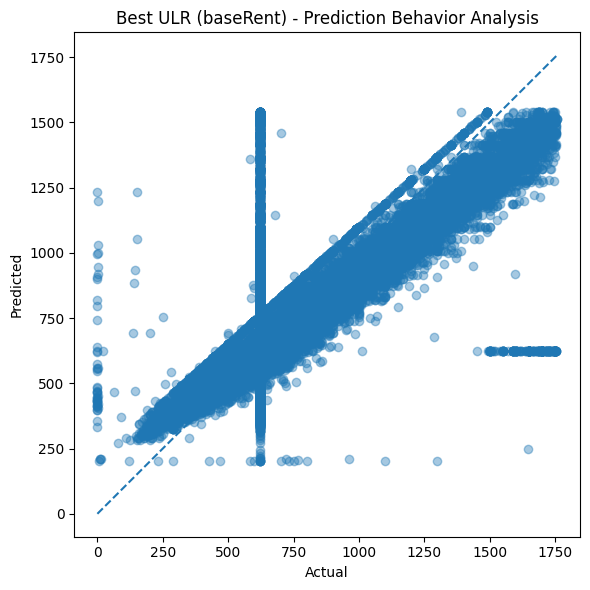

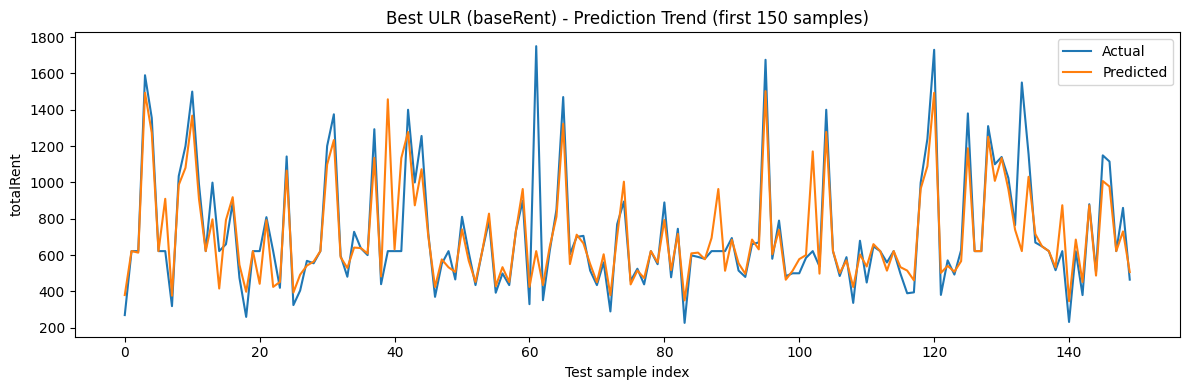


[Residual Analysis]


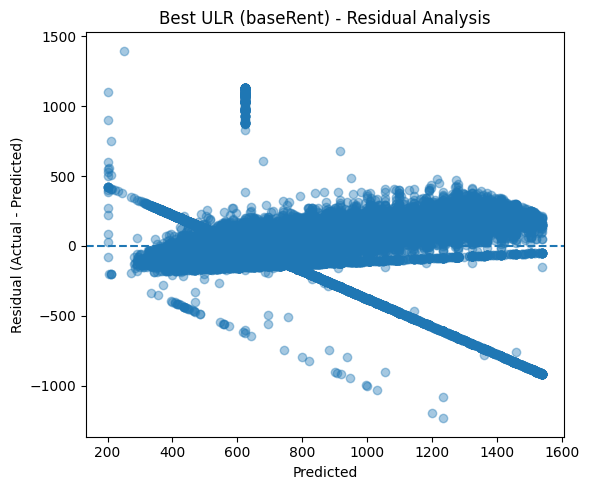


[Error Distribution Analysis]


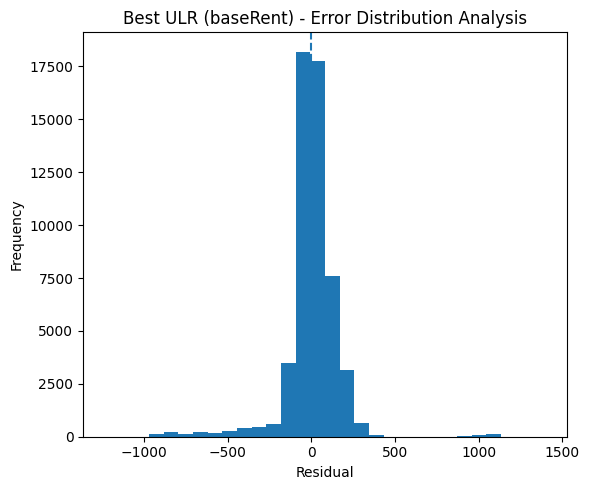


[Accuracy]
Accuracy summary:
 Accuracy_% : 54.76%  (|error| / |actual| <= 10%)

MODEL: Top 1 NLR (baseRent)


,n_samples,MAE,MSE,RMSE,R2,MAPE_%,Accuracy_%,Mean Residual,Std Residual
0,53770,89.280765,26017.279558,161.298728,0.735394,3.649457e+09,63.862749,3.323126,161.264492



[Prediction Behavior Analysis]


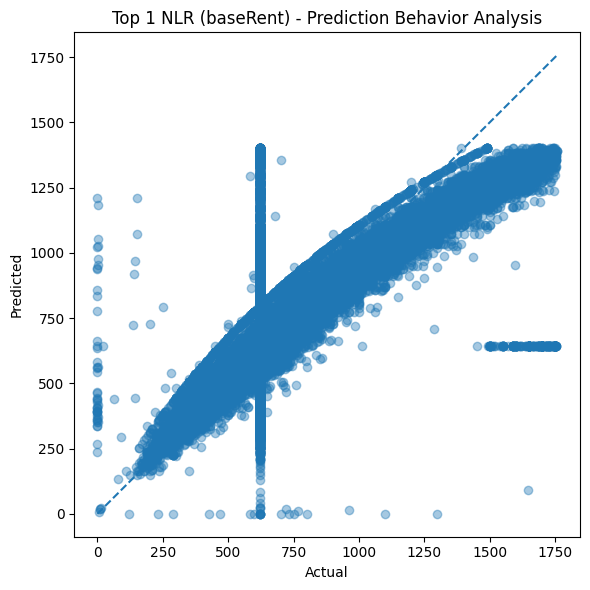

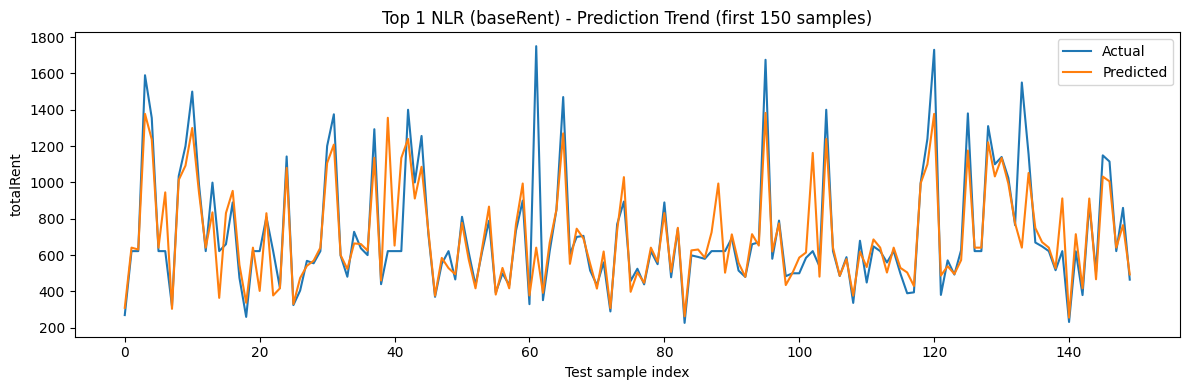


[Residual Analysis]


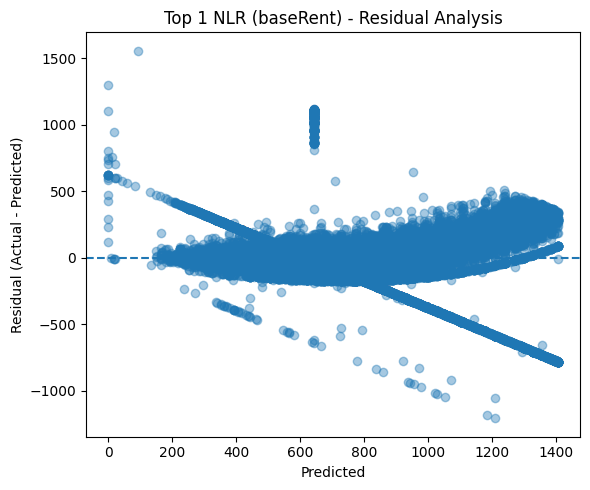


[Error Distribution Analysis]


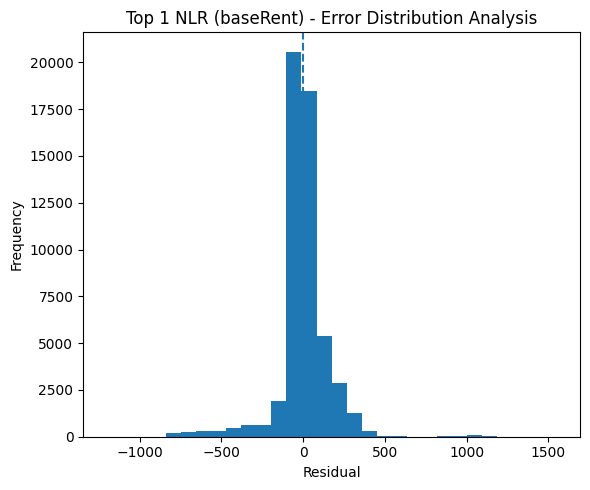


[Accuracy]
Accuracy summary:
 Accuracy_% : 63.86%  (|error| / |actual| <= 10%)

MODEL: Top 2 NLR (livingSpace)


,n_samples,MAE,MSE,RMSE,R2,MAPE_%,Accuracy_%,Mean Residual,Std Residual
0,53770,199.177572,69947.767485,264.476403,0.288604,4.705494e+09,18.434071,2.642277,264.463203



[Prediction Behavior Analysis]


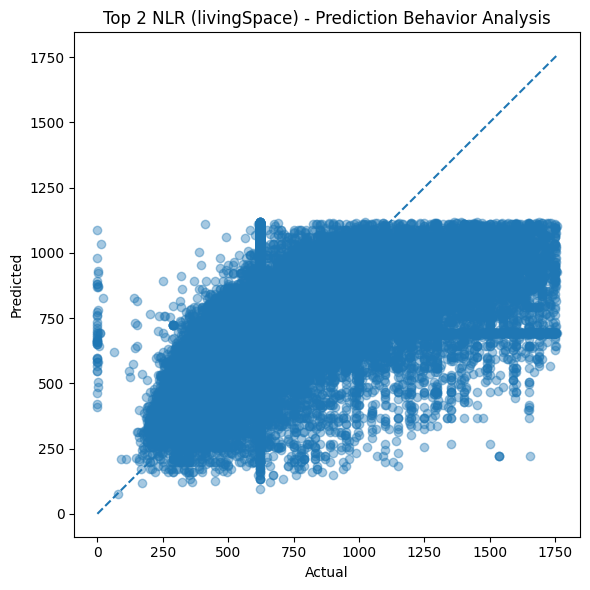

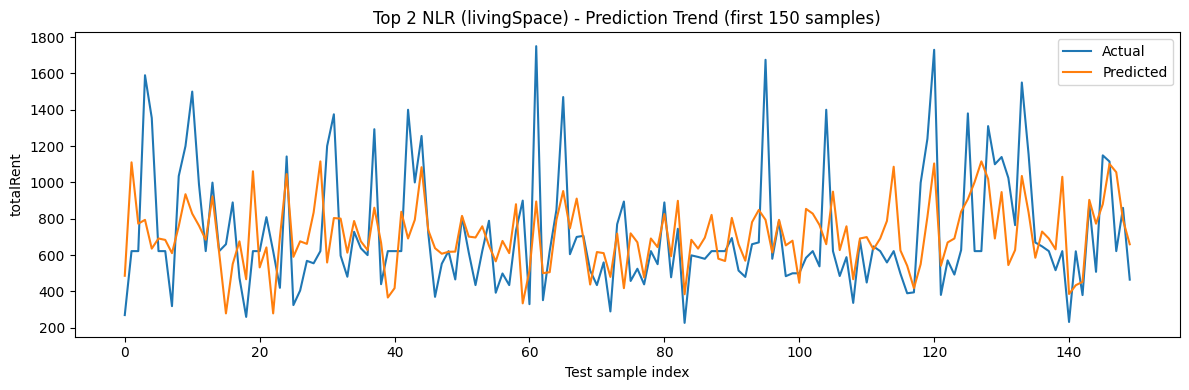


[Residual Analysis]


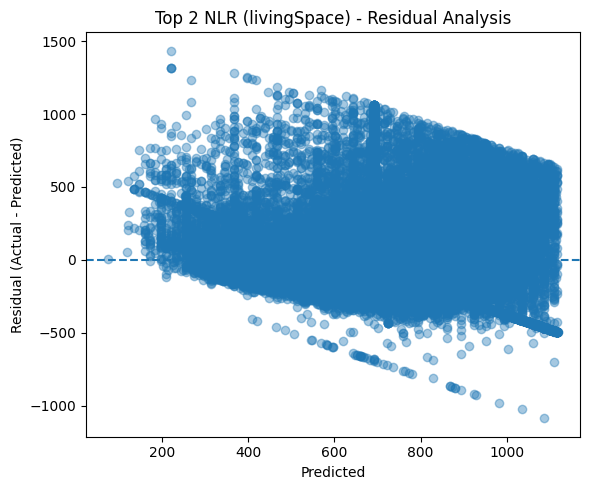


[Error Distribution Analysis]


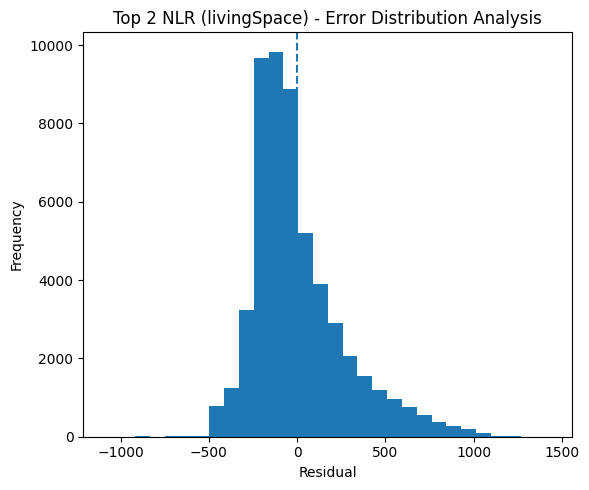


[Accuracy]
Accuracy summary:
 Accuracy_% : 18.43%  (|error| / |actual| <= 10%)

BẢNG ACCURACY CUỐI CÙNG


,model,n_samples,Accuracy_%
0,Top 1 NLR (baseRent),53770.0,63.862749
1,Best ULR (baseRent),53770.0,54.755440
2,Top 2 NLR (livingSpace),53770.0,18.434071



BEST MODEL THEO ACCURACY:
Top 1 NLR (baseRent) -> Accuracy_% = 63.86%


In [36]:
best_ulr_feature = ulr_val_ranked.iloc[0]["feature"]
top2_nlr_features = (
    nlr_val_ranked["feature"]
    .drop_duplicates()
    .head(2)
    .tolist()
)

if len(top2_nlr_features) < 2:
    print(f"Warning: Only {len(top2_nlr_features)} valid NLR models.")

selected_models_test = {}

feature_cols_with_baserent = feature_cols.copy()
try:
    X_test_ulr, y_test_ulr = prepare_xy(testdf, [best_ulr_feature], target_col)
    y_pred_ulr = ulr_models[best_ulr_feature].predict(X_test_ulr)

    selected_models_test[f"Best ULR ({best_ulr_feature})"] = {
        "family": "ULR",
        "feature": best_ulr_feature,
        "y_true": np.asarray(y_test_ulr, dtype=float),
        "y_pred": np.asarray(y_pred_ulr, dtype=float)
    }
except Exception as e:
    print(f"[ULR ERROR] {best_ulr_feature}: {e}")

# ----- MLR with baseRent -----
try:
    X_test_mlr_with, y_test_mlr_with = prepare_xy(testdf, feature_cols_with_baserent, target_col)
    y_pred_mlr_with = mlr_with_baserent.predict(X_test_mlr_with)

    selected_models_test["MLR with baseRent"] = {
        "family": "MLR",
        "feature": "with_baseRent",
        "y_true": np.asarray(y_test_mlr_with, dtype=float),
        "y_pred": np.asarray(y_pred_mlr_with, dtype=float)
    }
except Exception as e:
    print(f"[MLR WITH baseRent ERROR]: {e}")

feature_cols_without_baserent = [col for col in feature_cols if col != "baseRent"]
# ----- MLR without baseRent -----
try:
    X_test_mlr_without, y_test_mlr_without = prepare_xy(testdf, feature_cols_without_baserent, target_col)
    y_pred_mlr_without = mlr_without_baserent.predict(X_test_mlr_without)

    selected_models_test["MLR without baseRent"] = {
        "family": "MLR",
        "feature": "without_baseRent",
        "y_true": np.asarray(y_test_mlr_without, dtype=float),
        "y_pred": np.asarray(y_pred_mlr_without, dtype=float)
    }
except Exception as e:
    print(f"[MLR WITHOUT baseRent ERROR]: {e}")

# ----- Top 2 NLR -----
for i, feat in enumerate(top2_nlr_features, start=1):
    try:
        x_test_nlr, y_test_nlr = prepare_xy_nlr(testdf, feat, target_col)

        theta1 = nlr_params[feat]["theta1"]
        theta2 = nlr_params[feat]["theta2"]

        y_pred_nlr = nonlinear_model(x_test_nlr, theta1, theta2)

        selected_models_test[f"Top {i} NLR ({feat})"] = {
            "family": "NLR",
            "feature": feat,
            "y_true": np.asarray(y_test_nlr, dtype=float),
            "y_pred": np.asarray(y_pred_nlr, dtype=float)
        }
    except Exception as e:
        print(f"[NLR ERROR] {feat}: {e}")

if len(selected_models_test) == 0:
    raise ValueError("Không có model nào predict được trên test.csv")

# =========================================================
# 6. TÍNH METRICS
# =========================================================
per_model_metrics = {
    name: regression_metrics(info["y_true"], info["y_pred"], acc_tol=ACCURACY_TOLERANCE)
    for name, info in selected_models_test.items()
}

per_model_metrics_df = (
    pd.DataFrame(per_model_metrics)
    .T.reset_index()
    .rename(columns={"index": "model"})
    .sort_values(by=["RMSE", "MAE"], ascending=[True, True])
    .reset_index(drop=True)
)

# =========================================================
# 7. PLOT FUNCTIONS
# =========================================================

for name, info in selected_models_test.items():
    y_true = info["y_true"]
    y_pred = info["y_pred"]
    metrics = per_model_metrics[name]

    print("\n" + "=" * 100)
    print(f"MODEL: {name}")

    model_metric_df = pd.DataFrame([metrics])
    display(model_metric_df)

    print("\n[Prediction Behavior Analysis]")
    plot_prediction_behavior(name, y_true, y_pred)

    print("\n[Residual Analysis]")
    plot_residual_analysis(name, y_true, y_pred)

    print("\n[Error Distribution Analysis]")
    plot_error_distribution(name, y_true, y_pred)

    print("\n[Accuracy]")
    print_model_accuracy(metrics)

accuracy_summary_df = per_model_metrics_df[
    [
        "model",
        "n_samples",
        "Accuracy_%"
    ]
].copy()

accuracy_summary_df = accuracy_summary_df.sort_values(
    by="Accuracy_%", ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("BẢNG ACCURACY CUỐI CÙNG")
display(accuracy_summary_df)

best_model_by_accuracy = accuracy_summary_df.iloc[0]["model"]
best_accuracy_value = accuracy_summary_df.iloc[0]["Accuracy_%"]

print("\nBEST MODEL THEO ACCURACY:")
print(f"{best_model_by_accuracy} -> Accuracy_% = {best_accuracy_value:.2f}%")